In [6]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import GPy
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.spatial import distance
import statsmodels.api as sm
import warnings
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
from sklearn.cross_decomposition import CCA
import math
import copy
from math import log
from collections import Counter
import pickle
from sklearn.linear_model import Lasso
warnings.filterwarnings("ignore")

In [7]:
# Read beta back from the file
beta_star = np.load('beta_star.npy')
print("beta_star:", beta_star)
n_features = len(beta_star)

np.sum(beta_star[beta_star > 0])

beta_star: [ 0.          0.          0.          4.84313612  0.          0.
  0.          0.         -1.50046229  0.          0.          0.
  0.          0.          0.         -8.24601537  0.         -1.56670347
  0.          0.          3.59434365  0.         -2.95706303  0.
  0.          0.          7.16864507  0.          0.         -6.51835365
  0.          0.          0.          0.          0.          0.
  0.          1.00079185  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  5.26738719  0.        ]


21.874303886697408

In [20]:
from sklearn.linear_model import Lasso

def preconditioning_lasso_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star):
    """
    Implements the preconditioning LASSO bandit algorithm.

    Args:
        phi (float): Regularization parameter for optimization.
        T (int): Total time steps.
        C_max_wave (float): F_t matrix eigenvalue constraint.
        L (float): Upper limit for X values.
        error_std (float): Standard deviation for error term.
        Y_t (array): Initial response vector.
        X_t (array): Initial feature matrix.
        beta_star (array): True coefficient vector for simulation.

    Returns:
        Y_t, X_t: Updated response vector and feature matrix.
    """
    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)

        U_t, D_t, V_t_T = np.linalg.svd(X_t, full_matrices=False)
        # Compute F_t using the formula F_t = sqrt(t) * U_t @ D_t_inv @ U_t.T
        F_t = np.sqrt(tau) * U_t @ np.linalg.pinv(np.diag(D_t)) @ U_t.T
        # Compute transformed variables
        Y_t_tran = F_t @ Y_t
        X_t_tran = F_t @ X_t
        

        # Perform LASSO regression with lambda using Y_t_tran and X_t_tran
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t_tran, Y_t_tran)  # Fit the model to get beta estimates
        beta_esti = lasso.coef_  # Estimated beta values
        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")
        s_esti = np.count_nonzero(beta_esti)  # Number of non-zero coefficients

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            # Perform optimization to find X_max
            X_max = optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau)


        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max

        
        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)
        
        #print(f"time {tau}: beta {beta_esti}")
        print(f"time {tau}: reward {Y_max}")
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)

    return Y_t, X_t, Y_t_exp, l_2_error_parameter


In [21]:
def optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau):
    """
    Perform optimization using a hill-climbing algorithm under given constraints.

    Args:
        beta_esti (numpy array): Estimated coefficients (beta).
        s_esti (float): Estimated parameter for scaling.
        X_t (numpy array): Existing feature matrix.
        lamada (float): Regularization parameter.
        phi (float): Parameter for constraint.
        C_max_wave (float): Constraint for F_t matrix eigenvalue.
        t (int): Time step or scaling factor.
        max_iterations (int): Maximum number of iterations for the algorithm.

    Returns:
        numpy array: Optimized X_max vector.
    """
    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        sqrt_term = np.sqrt(X_max @ np.linalg.pinv((1 / tau) * (X_t.T @ X_t) ) @ X_max.reshape(-1, 1) * (np.sqrt(np.linalg.eigvalsh((1 / tau) * (X_t.T @ X_t)).max())))
        constant = (4 * np.sqrt(s_esti) * lamada / phi)
        return -(beta_esti @ X_max + constant * sqrt_term)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
        print("Optimal value:", objective(X_max_optimal))
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal


In [22]:
def while_preconditioning_lasso_bandit(beta_star):
    error_std = 1
    phi = 50
    C_max_wave = 1
    t = 2
    T = 1000 + t
    
    L = 1
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T, X_T, Y_t_exp, l_2_error_parameter = preconditioning_lasso_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp, l_2_error_parameter
    

In [23]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_preconditioning_lasso_bandit(beta_star)  # Replace with the actual function
    
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

# The results `cumulative_regre_times` and `l_2_error_parameter_times` now store the outcomes of all experiments.


parameter square error:15.506371928728665
Optimal value: [-0.]
time 2: reward [-2.37918496]
time 2: mean reward -1.529176055457318
parameter square error:15.506371928728665
Optimal value: [-0.]
time 3: reward [-5.18624816]
time 3: mean reward -4.781767476679406
parameter square error:15.506371928728665
Optimal value: [-0.]
time 4: reward [-3.80484352]
time 4: mean reward -4.5826110142014445
parameter square error:15.506371928728665
Optimal value: [-0.]
time 5: reward [6.76181266]
time 5: mean reward 7.773012388703759
parameter square error:15.506371928728665
Optimal value: [-0.]
time 6: reward [-4.30911111]
time 6: mean reward -3.706765666782899
parameter square error:15.506371928728665
Optimal value: [-0.]
time 7: reward [6.97629953]
time 7: mean reward 6.940535769578301
parameter square error:15.506371928728665
Optimal value: [-0.]
time 8: reward [-3.1602782]
time 8: mean reward -2.5041807517851007
parameter square error:15.506371928728665
Optimal value: [-0.]
time 9: reward [6.50010

In [24]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [  23.24604688   46.91827007   67.35643518 ... 1092.59048422 1092.59048422
 1092.59048422]
Cumulative Regret Std: [ 4.15396713  6.86788712  7.63074648 ... 46.95999805 46.95999805
 46.95999805]
L2 Error Parameter Mean: [1.55063719e+01 1.55063719e+01 1.55063719e+01 1.55063719e+01
 1.55063719e+01 1.55063719e+01 1.54840988e+01 1.53201825e+01
 1.51621804e+01 1.50721955e+01 1.49874969e+01 1.50232944e+01
 1.57753364e+01 1.92892739e+01 2.65300728e+01 4.37639863e+01
 7.80427638e+01 1.48570647e+02 2.92331815e+02 6.19349672e+02
 1.18120184e+03 2.37856660e+03 4.93282276e+03 1.13877730e+04
 2.48592742e+04 5.71445027e+04 1.17990686e+05 2.43254682e+05
 5.87955512e+05 1.08218935e+06 2.09235193e+06 4.35007425e+06
 7.54726109e+06 1.26403331e+07 2.37222320e+07 4.88431001e+07
 9.27765783e+07 1.81564865e+08 3.76007044e+08 9.54456822e+08
 2.74055904e+09 9.29143119e+09 2.37702542e+10 6.46143187e+10
 2.55580828e+11 1.24587708e+12 4.70724361e+12 6.62450179e+12
 3.33457333e+12 1.29869538

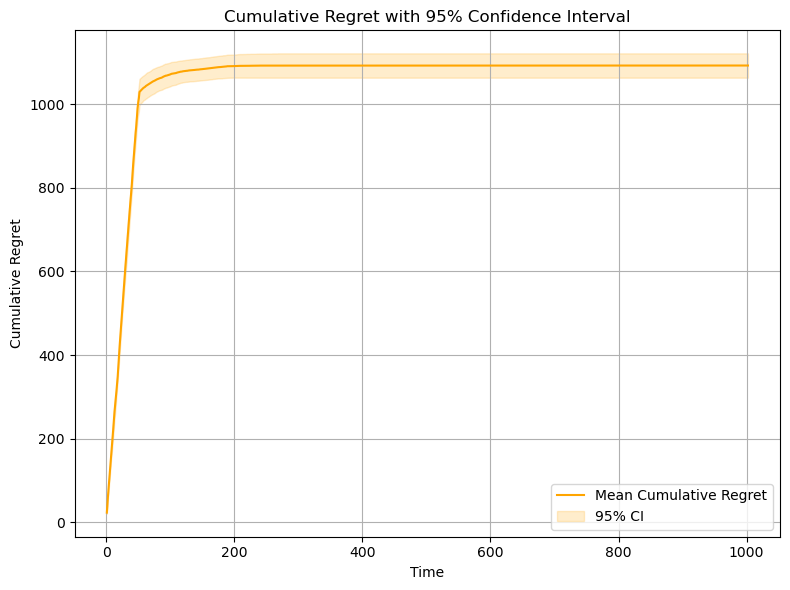

In [27]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [28]:
# 保存每个数组为单独的 .npy 文件
np.save('cumulative_regret_pre-lasso-stochastic-bandit-d50-s10_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_pre-lasso-stochastic-bandit-d50-s10_10times.npy', l_2_error_parameter_times)